# Phrase ↔ Vector: A Round-Trip Example

This notebook demonstrates how to:
1. **Phrase → Vector**: Convert a text phrase into numerical vector embeddings using a pre-trained BERT model.
2. **Vector → Phrase**: Decode the token IDs back to the original phrase.

We use [Hugging Face Transformers](https://huggingface.co/docs/transformers) with the `bert-base-uncased` model as a practical, self-contained example.

## 1. Import Required Libraries

We need:
- `transformers` — Hugging Face library for pre-trained NLP models.
- `torch` — PyTorch backend used by the model.
- `numpy` — For array manipulation.
- `matplotlib` / `sklearn` — For visualizing the embeddings in 2D.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import BertTokenizer, BertModel
from sklearn.decomposition import PCA

print("All libraries imported successfully.")
print(f"PyTorch version : {torch.__version__}")
print("Transformers    : OK")


c:\Users\ijchavar\OneDrive - Intel Corporation\Documents\PofC\GEN-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.
PyTorch version : 2.12.1+cpu
Transformers    : OK


## 2. Load a Pre-trained Tokenizer and Model

We use `bert-base-uncased`:
- **Tokenizer** — splits text into sub-word tokens and maps each to an integer ID.
- **Model** — a 12-layer transformer that produces a 768-dimensional embedding for every token.

The first run downloads the weights (~440 MB) and caches them locally.

In [2]:
MODEL_NAME = "bert-base-uncased"

# BertTokenizer converts text <-> token IDs
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

# BertModel produces contextualized vector embeddings
model = BertModel.from_pretrained(MODEL_NAME)
model.eval()  # set to inference mode (disables dropout)

print("="*50)
print(f"Model '{MODEL_NAME}' loaded.")
print(f"Vocabulary size : {tokenizer.vocab_size:,} tokens")
print(f"Embedding dim   : {model.config.hidden_size} dimensions per token")
print("="*50)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3529.60it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model 'bert-base-uncased' loaded.
Vocabulary size : 30,522 tokens
Embedding dim   : 768 dimensions per token


## 3. Phrase → Token IDs

The tokenizer splits the phrase into sub-word pieces (WordPiece algorithm) and adds two special tokens:
- `[CLS]` (ID 101) — marks the start of the sequence.
- `[SEP]` (ID 102) — marks the end of the sequence.

Each token is mapped to its integer ID in BERT's vocabulary.

In [3]:
PHRASE_TO_ANALYZE = "Artificial intelligence is transforming the world."

# tokenize: returns a dict with 'input_ids', 'attention_mask', etc.
encoding = tokenizer(PHRASE_TO_ANALYZE, return_tensors="pt")

input_ids = encoding["input_ids"]          # shape: [1, seq_len]
token_ids  = input_ids[0].tolist()         # list of integer IDs

# Recover the individual token strings for display
tokens = tokenizer.convert_ids_to_tokens(token_ids)

print("Original phrase :", PHRASE_TO_ANALYZE)
print()
print(f"{'Token':<20} {'ID':>6}")
print("-" * 28)
for tok, tid in zip(tokens, token_ids):
    print(f"{tok:<20} {tid:>6}")
print()
print(f"Sequence length : {len(token_ids)} tokens  (including [CLS] and [SEP])")


Original phrase : Artificial intelligence is transforming the world.

Token                    ID
----------------------------
[CLS]                   101
artificial             7976
intelligence           4454
is                     2003
transforming          17903
the                    1996
world                  2088
.                      1012
[SEP]                   102

Sequence length : 9 tokens  (including [CLS] and [SEP])


## 4. Token IDs → Vector Embeddings

Passing the token IDs through BERT produces `last_hidden_state`:  
a tensor of shape `[batch, seq_len, 768]`.

- Each row corresponds to one token.
- Each row is a **768-dimensional float vector** that captures the meaning of that token *in context*.

We also compute a **sentence embedding** by averaging all token vectors (mean pooling), which gives a single 768-D vector for the whole phrase.

In [8]:
with torch.no_grad():                        # no gradients needed for inference
    outputs = model(**encoding)
    vectors = outputs.last_hidden_state.squeeze(0).numpy()

# last_hidden_state: [batch=1, seq_len, hidden=768]
token_embeddings = outputs.last_hidden_state  # full per-token matrix
sentence_embedding = token_embeddings.mean(dim=1)  # mean-pool → [1, 768]

print("Tensor shape  (batch × tokens × dims) :", tuple(token_embeddings.shape))
print("sentence vec  (after mean-pool)        :", tuple(sentence_embedding.shape))
print()
print("First 8 values of the sentence embedding vector, size ", len(sentence_embedding[0]))
print(np.round(sentence_embedding[0, :8].numpy(), 8))
#print(np.round(sentence_embedding[0].numpy(), 8))


Tensor shape  (batch × tokens × dims) : (1, 9, 768)
sentence vec  (after mean-pool)        : (1, 768)

First 8 values of the sentence embedding vector, size  768
[ 0.2117744  -0.05316032 -0.09446167 -0.02964964  0.24797752 -0.4066404
  0.26826975  0.87729853]


## 5. Vector → Phrase (Round-Trip Decoding)

Going *back* from raw float vectors to text is not directly possible — the floating-point values carry *semantic meaning*, not an exact text encoding.  
What **is** reversible is the mapping between **token IDs** and **text**, because the tokenizer vocabulary is a bijection.

The cell below shows the full round-trip:  
`phrase → token IDs → (embedding) → token IDs → phrase`

In [9]:
# tokenizer.decode converts a list of token IDs back to a string.
# skip_special_tokens=True removes [CLS] and [SEP].
decoded_phrase = tokenizer.decode(token_ids, skip_special_tokens=True)

print("Original phrase :", PHRASE_TO_ANALYZE)
print("Decoded phrase  :", decoded_phrase)
print()
print("Round-trip match:", PHRASE_TO_ANALYZE.lower().rstrip(".") == decoded_phrase.lower().rstrip("."))

# --- Bonus: nearest-neighbour lookup in the vocabulary ---
# We can also ask: "which vocabulary token is closest to a given vector?"
# Here we check the [CLS] token embedding against the full embedding table.
embedding_matrix = model.embeddings.word_embeddings.weight  # [vocab_size, 768]
cls_vector = token_embeddings[0, 0, :]                      # [CLS] token vector

# Cosine similarity between [CLS] and every vocabulary embedding
cos_sim = torch.nn.functional.cosine_similarity(
    cls_vector.unsqueeze(0), embedding_matrix, dim=1
)
top5_ids   = cos_sim.topk(5).indices.tolist()
top5_words = tokenizer.convert_ids_to_tokens(top5_ids)
top5_scores = cos_sim.topk(5).values.tolist()

print("\nTop-5 vocabulary tokens closest to [CLS] vector (cosine similarity):")
for word, score in zip(top5_words, top5_scores):
    print(f"  {word:<20} {score:.4f}")


Original phrase : Artificial intelligence is transforming the world.
Decoded phrase  : artificial intelligence is transforming the world.

Round-trip match: True

Top-5 vocabulary tokens closest to [CLS] vector (cosine similarity):
  nervous              0.1173
  social               0.1130
  dem                  0.1072
  visual               0.1038
  racial               0.1020


## 6. Visualize the Embeddings

BERT produces 768-dimensional vectors — impossible to plot directly.  
We use **PCA** (Principal Component Analysis) to project each token's vector down to 2D so we can see how the tokens cluster in semantic space.

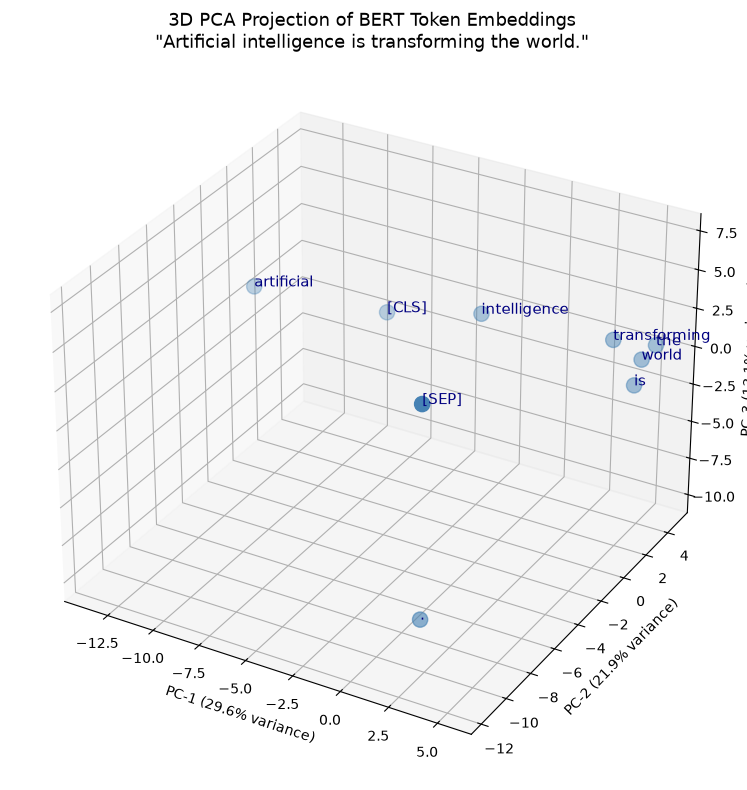


Total variance captured by 3 components: 64.7%


In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Reduce to 3D using PCA (n_components changed to 3)
pca = PCA(n_components=3)
coords = pca.fit_transform(vectors)  # New shape: [seq_len, 3]

# 2. Create a figure and a 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")  # Enables 3D projection

# 3. Plot the points in 3D (adding the third column of coords)
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=120, color="steelblue", zorder=3)

# 4. Add the token labels with (x, y, z) coordinates
for i, (tok, (x, y, z)) in enumerate(zip(tokens, coords)):
    ax.text(
        x,
        y,
        z,
        tok,
        color="navy",
        fontsize=11,
    )

# 5. Configure titles and labels for the 3 axes
ax.set_title(
    f'3D PCA Projection of BERT Token Embeddings\n"{PHRASE_TO_ANALYZE}"',
    fontsize=13,
)
ax.set_xlabel(f"PC-1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC-2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_zlabel(f"PC-3 ({pca.explained_variance_ratio_[2]*100:.1f}% variance)")

plt.tight_layout()
plt.show()

# 6. Display total variance captured by the 3 components
print(
    f"\nTotal variance captured by 3 components: "
    f"{sum(pca.explained_variance_ratio_)*100:.1f}%"
)
